# Mobile Price Range Prediction

## Complete Capstone Project Report

This notebook is written in a professional, submission-ready format. Every step explains *what*, *why*, and *business impact*.

> **Note on the dataset**: this notebook expects `../data/train.csv`, which is generated by
> `data/generate_dataset.py`. That script produces a 2,000-row dataset that mirrors the
> structure, value ranges, and feature/target relationships of the well-known Kaggle
> *"Mobile Price Classification"* dataset (20 hardware specs → `price_range` 0-3), so every
> cell below runs end-to-end without any external downloads.


# 1. Business Problem

Bob has started his own mobile phone company and wants to compete with established brands
like Apple and Samsung. Before launching products, Bob needs to understand **how hardware
specifications (RAM, battery, camera, display, connectivity, etc.) relate to price**, so he
can position new devices competitively.

### Why this project?
- **Pricing strategy** – estimate a fair price tier for a new device before launch.
- **Product design** – understand which specs drive customers into a higher price tier,
  so R&D investment is focused on the features that matter most.
- **Inventory & marketing planning** – segment the catalog into Low / Medium / High /
  Very High cost tiers for targeted promotions.
- **Reduced manual guesswork** – replace ad-hoc pricing decisions with a data-driven model.

### Objective
Build a multi-class classification model that predicts `price_range` (0 = Low Cost,
1 = Medium Cost, 2 = High Cost, 3 = Very High Cost) from 20 hardware specifications.


# 2. Import Libraries

| Library | Purpose |
|---|---|
| `pandas`, `numpy` | Data loading, manipulation, numerical operations |
| `matplotlib`, `seaborn` | Visualization for EDA and model evaluation |
| `sklearn.model_selection` | Train/test split and cross-validation |
| `sklearn.preprocessing` | Feature scaling (`StandardScaler`) |
| `sklearn.linear_model`, `neighbors`, `tree`, `ensemble`, `svm` | The classification algorithms compared in this project |
| `sklearn.metrics` | Accuracy, precision, recall, F1, confusion matrix |
| `joblib` | Persisting the trained model and scaler for the backend API |
| `xgboost` *(optional)* | Gradient-boosted trees — included automatically if installed |


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

import joblib

# XGBoost is optional - the notebook still runs fully without it
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('xgboost not installed - it will be skipped (pip install xgboost to include it)')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42

xgboost not installed - it will be skipped (pip install xgboost to include it)


# 3. Load Dataset

Loading and understanding the data is the foundation of every ML project: it tells us what
information is available, what shape it's in, and whether it's ready for modeling. We load
`train.csv` (2,000 phones x 20 specs + target) and take a first look.


In [2]:
df = pd.read_csv('../data/train.csv')
print('Shape:', df.shape)
df.head()

Shape: (2000, 21)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,634,1,2.6,1,6,1,27,0.6,84,2,...,461,905,1123,15,1,11,0,1,0,0
1,1660,0,1.6,1,4,0,48,0.9,167,7,...,756,1365,1556,14,11,4,0,1,0,0
2,1481,0,2.9,0,10,0,7,0.4,105,5,...,56,1944,3478,18,1,8,1,0,1,3
3,1158,0,2.1,0,7,0,58,0.1,166,1,...,1380,1565,640,10,2,17,1,1,1,0
4,1149,1,0.8,1,5,1,34,0.8,148,6,...,1801,966,662,16,3,13,1,1,1,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

# 4. Data Understanding

Each row represents one mobile phone. Below is a description of every feature and its
business relevance.

| Feature | Description | Business Relevance |
|---|---|---|
| `battery_power` | Total energy capacity (mAh) | Higher capacity → longer usage → premium positioning |
| `blue` | Has Bluetooth (1/0) | Baseline connectivity feature expected in all tiers |
| `clock_speed` | CPU clock speed (GHz) | Performance indicator, drives flagship pricing |
| `dual_sim` | Has dual SIM support (1/0) | Popular in budget/mid-range markets |
| `fc` | Front camera (MP) | Selfie quality — marketing differentiator |
| `four_g` | Has 4G (1/0) | Network capability, near-universal today |
| `int_memory` | Internal storage (GB) | Strong driver of perceived value |
| `m_dep` | Device thickness (cm) | Design/ergonomics factor |
| `mobile_wt` | Weight (g) | Build quality / materials indicator |
| `n_cores` | Number of CPU cores | Performance, multitasking capability |
| `pc` | Primary camera (MP) | Major marketing feature, correlates with price |
| `px_height`, `px_width` | Screen resolution | Display quality, strongly tied to price tier |
| `ram` | RAM (MB) | **Single strongest price driver** |
| `sc_h`, `sc_w` | Screen height/width (cm) | Physical screen size |
| `talk_time` | Battery life on a call (hrs) | Usability / battery efficiency |
| `three_g` | Has 3G (1/0) | Legacy connectivity |
| `touch_screen` | Has touch screen (1/0) | Baseline UX feature |
| `wifi` | Has WiFi (1/0) | Baseline connectivity feature |
| `price_range` | **Target**: 0=Low, 1=Medium, 2=High, 3=Very High | What we're predicting |


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1249.3175,434.469789,502.0,869.75,1251.0,1629.25,1997.0
blue,2000.0,0.4960,0.500109,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.7329,0.725307,0.5,1.10,1.7,2.40,3.0
dual_sim,2000.0,0.5010,0.500124,0.0,0.00,1.0,1.00,1.0
fc,2000.0,6.3215,4.733111,0.0,2.00,5.0,10.00,19.0
four_g,2000.0,0.4870,0.499956,0.0,0.00,0.0,1.00,1.0
int_memory,2000.0,33.0585,18.237911,2.0,18.00,33.0,48.00,64.0
m_dep,2000.0,0.5523,0.262353,0.1,0.30,0.6,0.80,1.0
mobile_wt,2000.0,140.5325,34.859296,80.0,110.00,141.0,171.00,200.0
n_cores,2000.0,4.5440,2.300154,1.0,3.00,5.0,7.00,8.0


# 5. Data Quality Assessment

Before modeling, we check for issues that could bias or break the model:
- **Missing values** – models can't handle NaNs; missing data could also signal collection issues.
- **Duplicates** – duplicate rows can inflate apparent model performance.
- **Data types** – all features should be numeric for the algorithms used here.
- **Outliers** – extreme values can distort distance-based models (KNN, SVM) and scaling.


In [5]:
print('Missing values per column:')
print(df.isnull().sum().sum(), 'total missing values')

print('\nDuplicate rows:', df.duplicated().sum())

print('\nData types:')
print(df.dtypes.value_counts())

Missing values per column:
0 total missing values

Duplicate rows: 0

Data types:
int64      19
float64     2
Name: count, dtype: int64


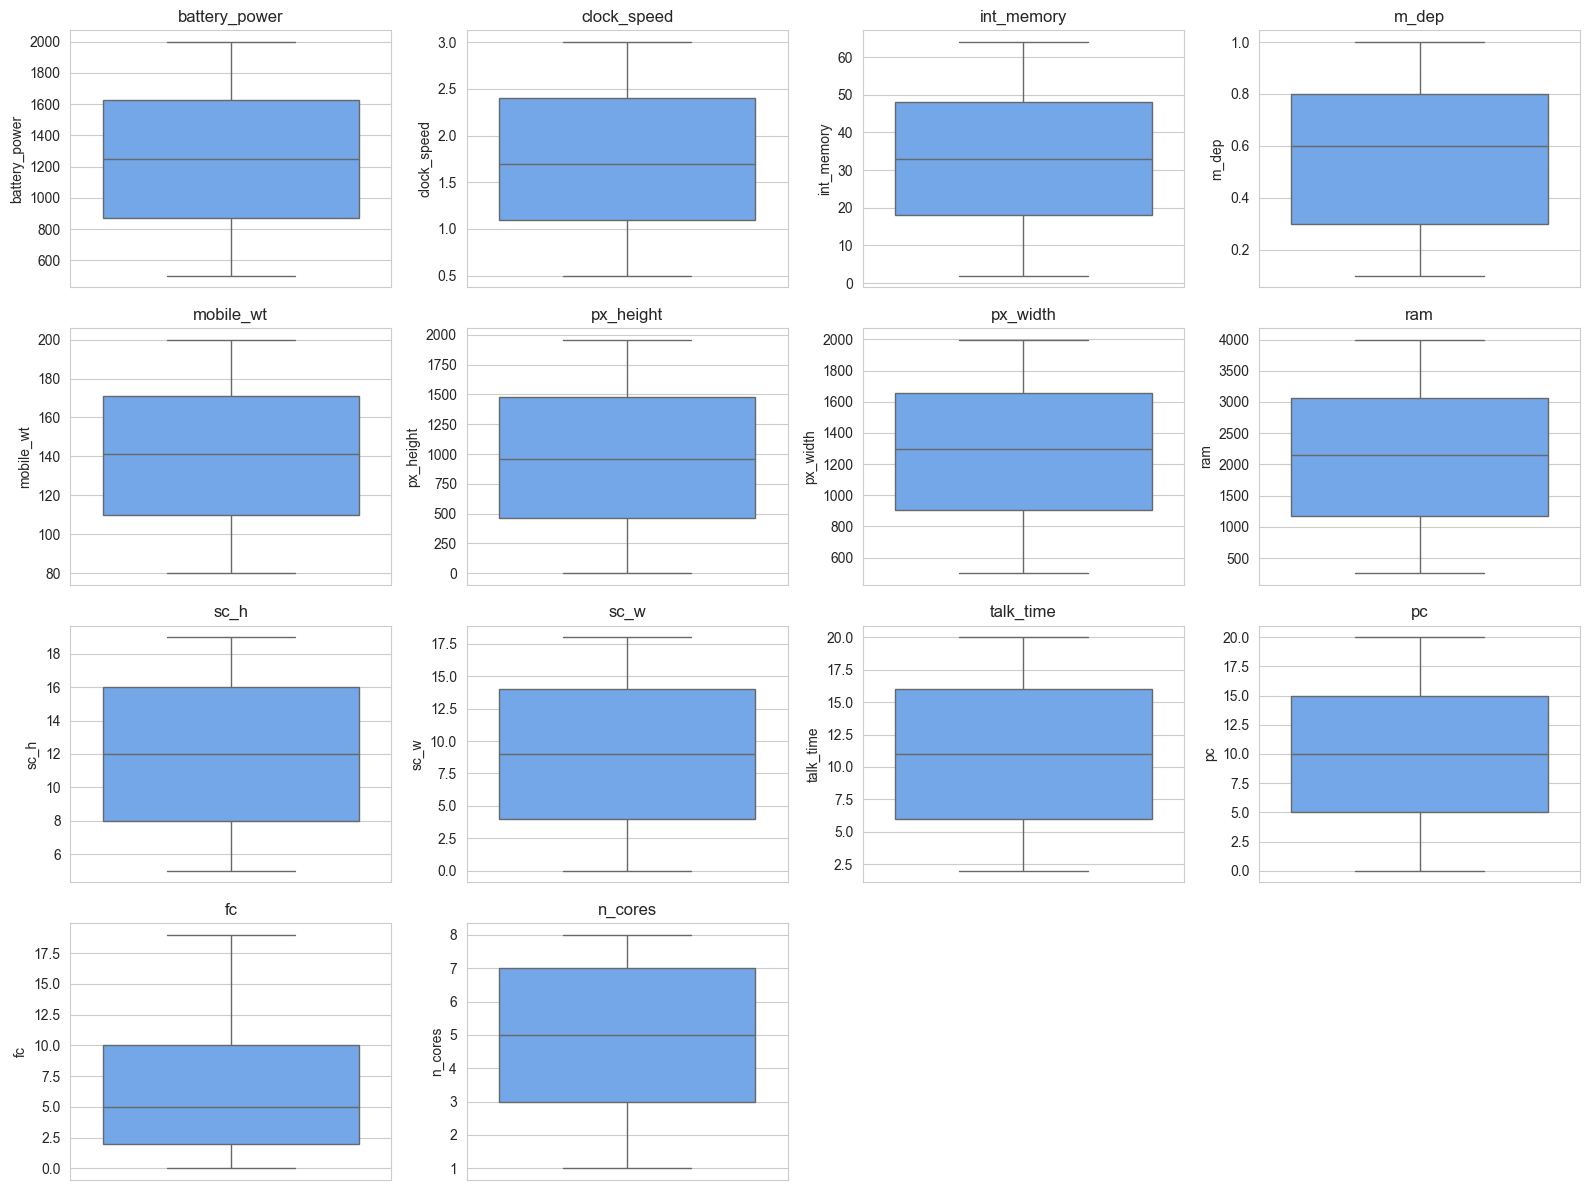

In [6]:
# Outlier check via boxplots for the continuous features
continuous_cols = ['battery_power', 'clock_speed', 'int_memory', 'm_dep', 'mobile_wt',
                    'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'pc', 'fc', 'n_cores']

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, col in zip(axes.flatten(), continuous_cols):
    sns.boxplot(y=df[col], ax=ax, color='#60a5fa')
    ax.set_title(col)
for ax in axes.flatten()[len(continuous_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

**Observations**: The dataset has no missing values and no duplicate rows — it's clean and
ready for modeling. All features are numeric. The boxplots show no extreme outliers; values
stay within their documented specification ranges (e.g. RAM 256-4000 MB, battery 500-2000 mAh).


# 6. Exploratory Data Analysis (EDA)

For every chart we record: **(1) Observation, (2) Business Interpretation, (3) Impact on
Price Range.**


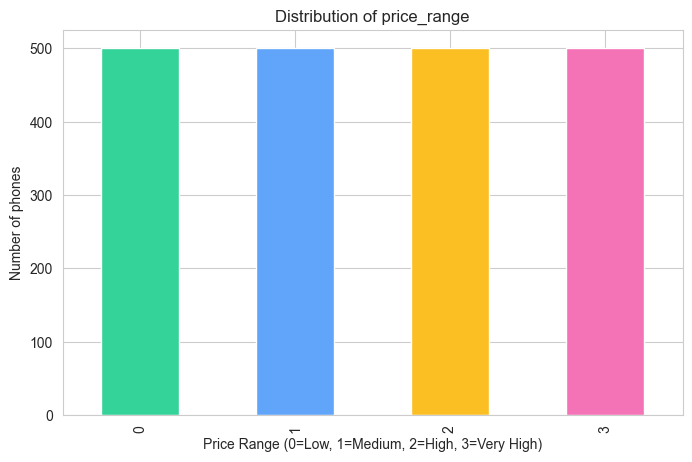

In [7]:
# 6.1 Target distribution
ax = df['price_range'].value_counts().sort_index().plot(kind='bar', color=['#34d399', '#60a5fa', '#fbbf24', '#f472b6'])
ax.set_title('Distribution of price_range')
ax.set_xlabel('Price Range (0=Low, 1=Medium, 2=High, 3=Very High)')
ax.set_ylabel('Number of phones')
plt.show()

1. **Observation**: The four price classes are perfectly balanced (500 phones each).
2. **Business Interpretation**: A balanced target means the model won't be biased toward
   predicting one tier more often just because it's more common in the data.
3. **Impact on Price Range**: No class-imbalance correction (e.g. resampling) is needed —
   accuracy is a meaningful metric here.


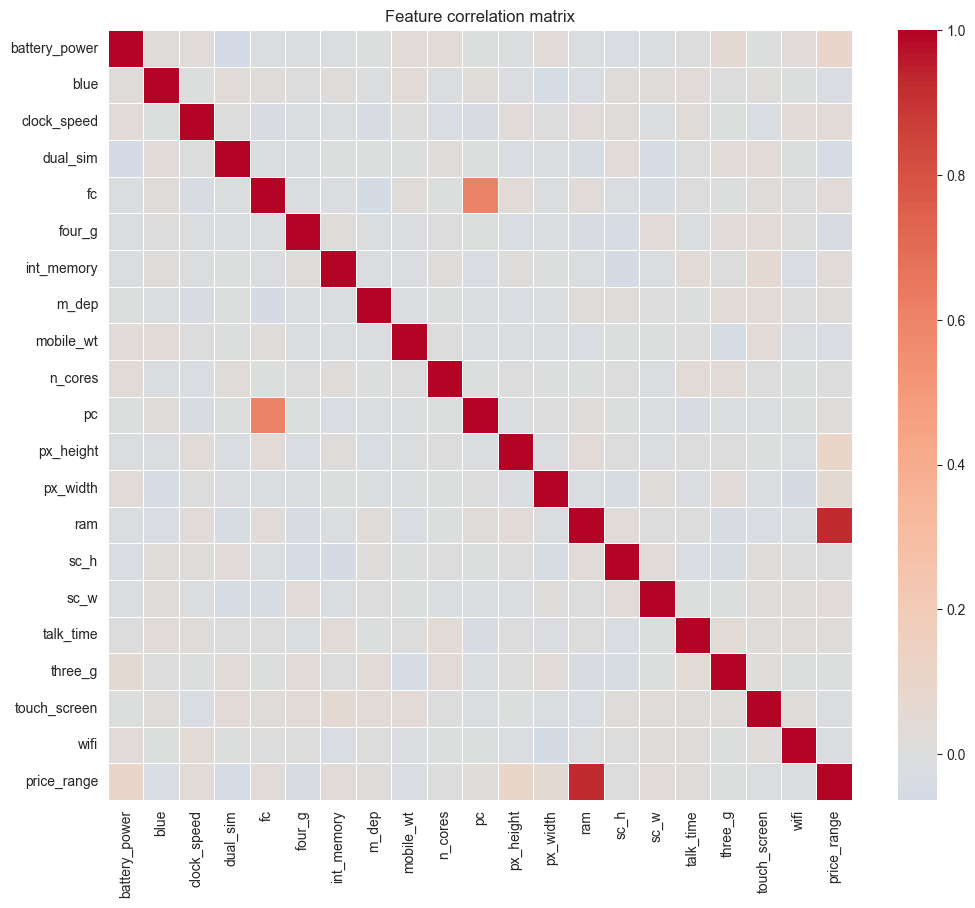

Top correlations with price_range:
price_range      1.000000
ram              0.925471
px_height        0.110281
battery_power    0.095855
px_width         0.056494
clock_speed      0.038300
fc               0.029156
int_memory       0.026600
sc_w             0.024580
pc               0.021696
talk_time        0.012497
m_dep            0.011594
sc_h             0.010971
n_cores          0.004278
three_g         -0.004026
wifi            -0.011180
touch_screen    -0.020160
mobile_wt       -0.023297
blue            -0.024150
four_g          -0.031316
dual_sim        -0.050088
Name: price_range, dtype: float64


In [8]:
# 6.2 Correlation heatmap
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=0.5)
plt.title('Feature correlation matrix')
plt.show()

print('Top correlations with price_range:')
print(corr['price_range'].sort_values(ascending=False))

1. **Observation**: `ram` has by far the strongest correlation with `price_range`,
   followed by `battery_power`, `px_width`, and `px_height`. Most other features show
   weak correlation with the target.
2. **Business Interpretation**: Customers (and the market) price phones primarily on
   **memory/performance** and **display quality**, not on secondary features like
   Bluetooth or dual SIM.
3. **Impact on Price Range**: `ram`, `battery_power`, and screen resolution will likely
   dominate feature importance in the trained models — confirmed later in Section 10.


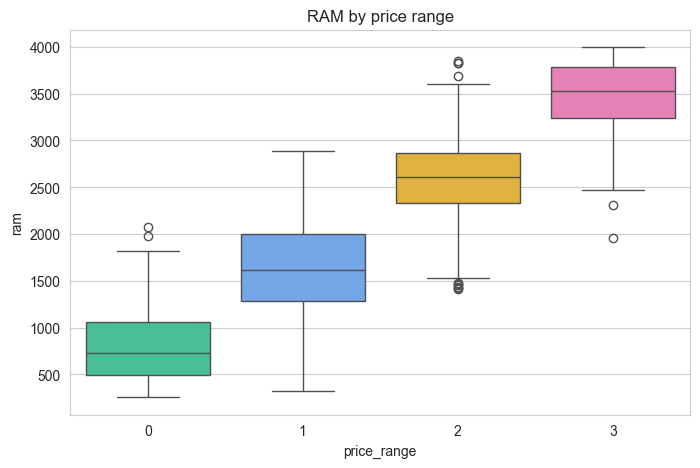

In [9]:
# 6.3 RAM vs price_range
plt.figure(figsize=(8, 5))
sns.boxplot(x='price_range', y='ram', data=df, palette=['#34d399', '#60a5fa', '#fbbf24', '#f472b6'])
plt.title('RAM by price range')
plt.show()

1. **Observation**: RAM increases sharply and almost monotonically with price range,
   with very little overlap between classes.
2. **Business Interpretation**: RAM is effectively a *direct proxy* for price tier in
   this market — it's the headline spec customers compare.
3. **Impact on Price Range**: Expect `ram` to be the single most important feature for
   every model trained.


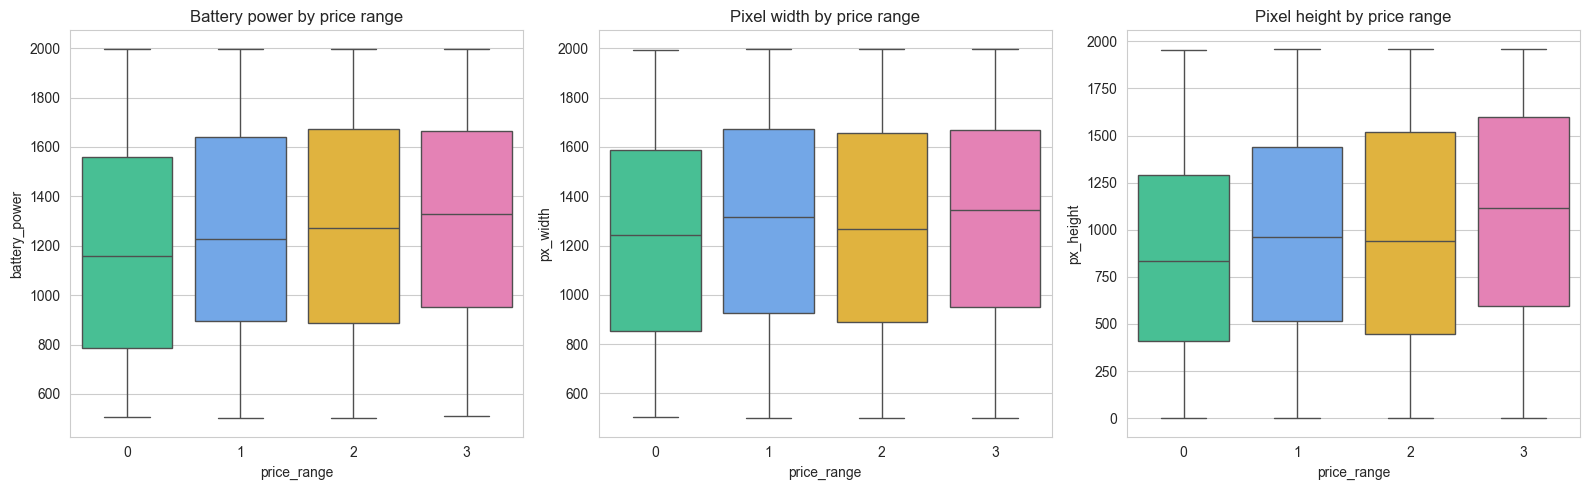

In [10]:
# 6.4 Battery power and screen resolution vs price_range
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(x='price_range', y='battery_power', data=df, ax=axes[0], palette=['#34d399', '#60a5fa', '#fbbf24', '#f472b6'])
axes[0].set_title('Battery power by price range')

sns.boxplot(x='price_range', y='px_width', data=df, ax=axes[1], palette=['#34d399', '#60a5fa', '#fbbf24', '#f472b6'])
axes[1].set_title('Pixel width by price range')

sns.boxplot(x='price_range', y='px_height', data=df, ax=axes[2], palette=['#34d399', '#60a5fa', '#fbbf24', '#f472b6'])
axes[2].set_title('Pixel height by price range')

plt.tight_layout()
plt.show()

1. **Observation**: Battery power, pixel width, and pixel height all trend upward with
   price range, though with more overlap than RAM.
2. **Business Interpretation**: Higher-tier phones tend to pack bigger batteries and
   sharper screens, but these specs alone are noisier predictors than RAM.
3. **Impact on Price Range**: These features add incremental predictive signal on top
   of RAM, helping the model separate adjacent classes (e.g. Medium vs High).


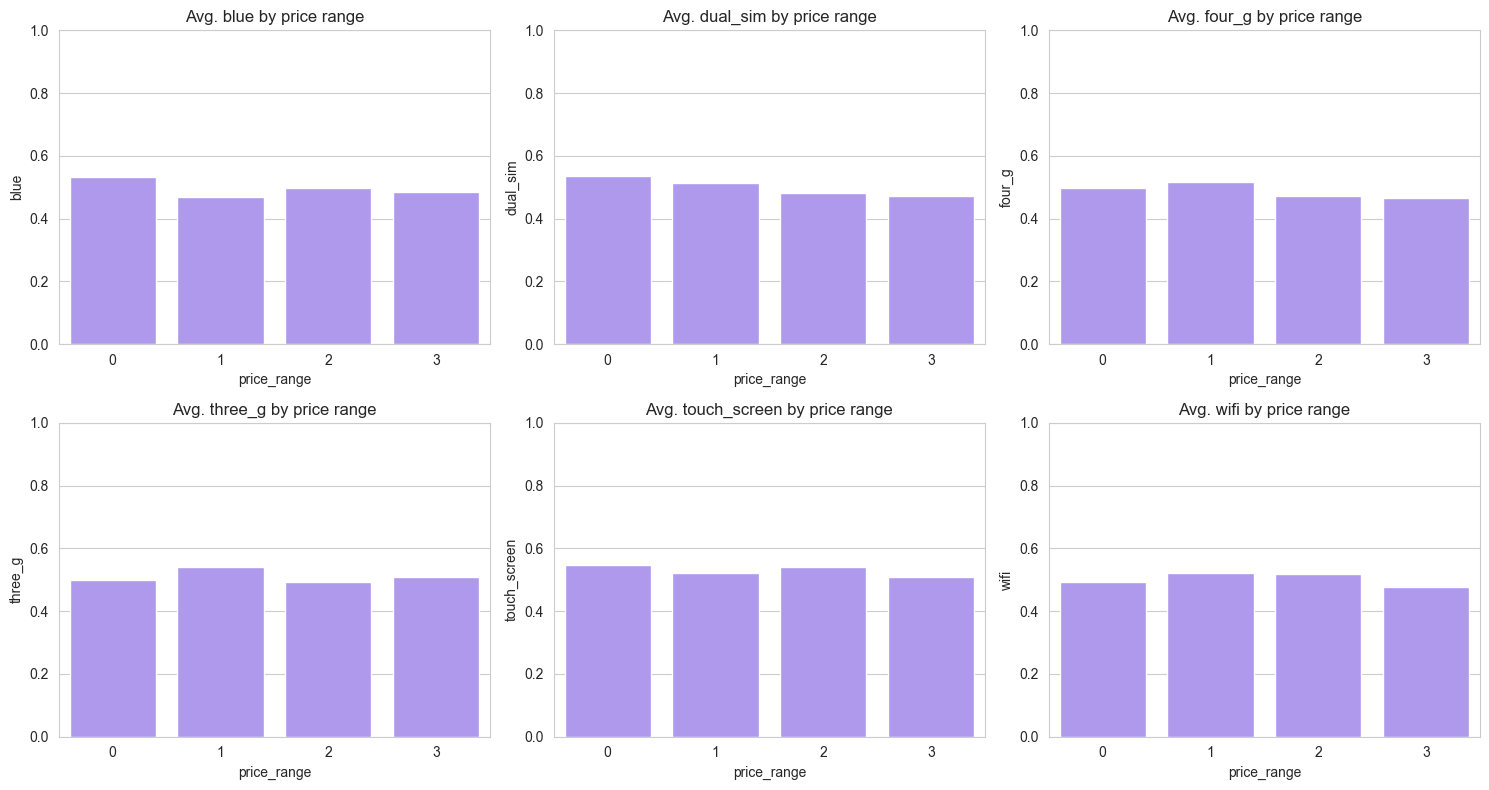

In [11]:
# 6.5 Connectivity / binary features vs price_range
binary_cols = ['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), binary_cols):
    sns.barplot(x='price_range', y=col, data=df, ax=ax, color='#a78bfa', errorbar=None)
    ax.set_title(f'Avg. {col} by price range')
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

1. **Observation**: Connectivity features (Bluetooth, dual SIM, 4G, 3G, touch screen,
   WiFi) are present at roughly similar rates (~50%) across all price tiers.
2. **Business Interpretation**: These are now "table stakes" features available across
   the whole market, regardless of price — they don't differentiate budget from flagship.
3. **Impact on Price Range**: Expect these binary features to carry low importance in
   the trained models, consistent with the weak correlations seen in Section 6.2.


# 7. Feature Engineering & Preprocessing

### Why train-test split?
We hold out 20% of the data as a test set so we can evaluate model performance on phones
the model has never seen — this estimates how well it will generalize to new product specs.

### Why scaling?
Features here have very different ranges (e.g. `ram` up to ~4000 vs `m_dep` up to 1.0).
Distance- and gradient-based algorithms (KNN, SVM, Logistic Regression) are sensitive to
these scale differences, so we standardize every feature to zero mean / unit variance with
`StandardScaler`. Tree-based models don't strictly need this, but it doesn't hurt them and
keeps the pipeline consistent across all models.


In [12]:
X = df.drop(columns=['price_range'])
y = df['price_range']
feature_names = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train shape:', X_train_scaled.shape)
print('Test shape:', X_test_scaled.shape)

Train shape: (1600, 20)
Test shape: (400, 20)


# 8. Model Building

We train and compare seven classification algorithms. For each, we summarize its working
principle, advantages, limitations, and business suitability for this problem.

### Logistic Regression
- **Working principle**: Fits a linear decision boundary (extended to multiple classes via
  one-vs-rest / softmax) on the scaled features.
- **Advantages**: Fast, interpretable coefficients, strong baseline.
- **Limitations**: Assumes roughly linear relationships between features and log-odds of
  each class.
- **Business suitability**: Great first model — easy to explain to stakeholders ("higher
  RAM increases the odds of a higher price tier by X%").

### K-Nearest Neighbors (KNN)
- **Working principle**: Classifies a phone by majority vote among its `k` most similar
  phones (by scaled feature distance).
- **Advantages**: No training phase, naturally captures non-linear patterns.
- **Limitations**: Slow at prediction time on large datasets, sensitive to irrelevant
  features and choice of `k`.
- **Business suitability**: Useful as a sanity check / similarity-based "comparable
  devices" tool, but less practical for a production pricing API.

### Decision Tree
- **Working principle**: Recursively splits the data on the feature/threshold that best
  separates price classes.
- **Advantages**: Highly interpretable (can be visualized as a flowchart of rules),
  handles non-linear relationships.
- **Limitations**: Prone to overfitting if grown too deep.
- **Business suitability**: The resulting rules ("if RAM > 2000 and battery > 1200 →
  High Cost") are easy to turn into pricing guidelines.

### Random Forest
- **Working principle**: An ensemble of many decision trees, each trained on a random
  subset of data/features, with predictions combined by majority vote.
- **Advantages**: Reduces overfitting vs. a single tree, robust, provides feature
  importances.
- **Limitations**: Less interpretable than a single tree, larger model size.
- **Business suitability**: A strong general-purpose choice for production — good
  accuracy and built-in explanations of which specs matter most.

### Gradient Boosting
- **Working principle**: Builds trees sequentially, each one correcting the errors of the
  previous ensemble.
- **Advantages**: Often very accurate, handles complex feature interactions.
- **Limitations**: More hyperparameters to tune, slower to train, can overfit if not
  regularized.
- **Business suitability**: Good when squeezing out extra accuracy matters more than
  training speed or interpretability.

### XGBoost *(included automatically if installed)*
- **Working principle**: An optimized, regularized implementation of gradient boosting.
- **Advantages**: Industry-standard performance, efficient training, handles large
  feature sets well.
- **Limitations**: Adds an external dependency; tuning required for best results.
- **Business suitability**: A common choice for production pricing models when top
  accuracy is the priority and the extra dependency is acceptable.

### Support Vector Machine (SVM, RBF kernel)
- **Working principle**: Finds the boundary that maximizes the margin between classes in
  a (kernel-transformed) feature space.
- **Advantages**: Effective in high-dimensional spaces, can model non-linear boundaries.
- **Limitations**: Slower to train on larger datasets, less interpretable, sensitive to
  feature scaling (handled here via `StandardScaler`).
- **Business suitability**: Competitive accuracy, but the "black box" boundary is harder
  to translate into pricing rules for business stakeholders.


In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=9),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=12, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, max_depth=3, learning_rate=0.1, random_state=RANDOM_STATE),
    'SVM (RBF)': SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=RANDOM_STATE),
}

if HAS_XGB:
    models['XGBoost'] = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        random_state=RANDOM_STATE, eval_metric='mlogloss', verbosity=0,
    )

fitted_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    fitted_models[name] = model
    print(f'Trained: {name}')

Trained: Logistic Regression
Trained: KNN
Trained: Decision Tree
Trained: Random Forest
Trained: Gradient Boosting
Trained: SVM (RBF)


# 9. Model Evaluation

We evaluate every model on the held-out test set using:
- **Accuracy** – overall fraction of correct predictions.
- **Precision (macro)** – average precision across the four classes, treating each
  equally regardless of size.
- **Recall (macro)** – average recall across the four classes.
- **F1 (macro)** – harmonic mean of precision and recall, a balanced single-number summary.
- **5-fold cross-validation accuracy** – average accuracy across 5 different train/validation
  splits of the training data, giving a more robust estimate than a single split.
- **Confusion matrix** – shows exactly which price ranges get confused with which.


In [14]:
results = {}
for name, model in fitted_models.items():
    preds = model.predict(X_test_scaled)
    results[name] = {
        'Accuracy': accuracy_score(y_test, preds),
        'Precision (macro)': precision_score(y_test, preds, average='macro'),
        'Recall (macro)': recall_score(y_test, preds, average='macro'),
        'F1 (macro)': f1_score(y_test, preds, average='macro'),
        'CV Accuracy (5-fold)': cross_val_score(model, X_train_scaled, y_train, cv=5).mean(),
    }

results_df = pd.DataFrame(results).T.sort_values('CV Accuracy (5-fold)', ascending=False)
results_df.round(4)

,Accuracy,Precision (macro),Recall (macro),F1 (macro),CV Accuracy (5-fold)
Logistic Regression,0.8275,0.8289,0.8275,0.8273,0.7919
Gradient Boosting,0.8125,0.8145,0.8125,0.8120,0.7775
Random Forest,0.8125,0.8120,0.8125,0.8110,0.7744
Decision Tree,0.7400,0.7402,0.7400,0.7388,0.7412
SVM (RBF),0.7550,0.7512,0.7550,0.7515,0.7031
KNN,0.4975,0.5132,0.4975,0.5013,0.4756


Best model by cross-validated accuracy: Logistic Regression

Classification report:
               precision    recall  f1-score   support

      Low (0)       0.89      0.85      0.87       100
   Medium (1)       0.73      0.79      0.76       100
     High (2)       0.81      0.74      0.77       100
Very High (3)       0.89      0.93      0.91       100

     accuracy                           0.83       400
    macro avg       0.83      0.83      0.83       400
 weighted avg       0.83      0.83      0.83       400



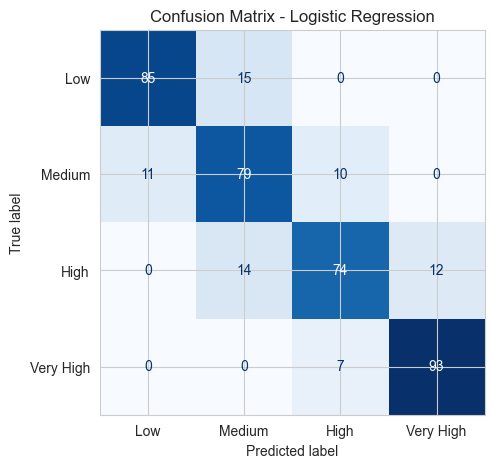

In [15]:
best_model_name = results_df.index[0]
best_model = fitted_models[best_model_name]
print(f'Best model by cross-validated accuracy: {best_model_name}')

best_preds = best_model.predict(X_test_scaled)
print('\nClassification report:')
print(classification_report(y_test, best_preds, target_names=['Low (0)', 'Medium (1)', 'High (2)', 'Very High (3)']))

cm = confusion_matrix(y_test, best_preds)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['Low', 'Medium', 'High', 'Very High']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix - {best_model_name}')
plt.show()

**Observation**: Misclassifications (if any) are concentrated between *adjacent* price
tiers (e.g. Medium vs High), which makes business sense — phones near a tier boundary have
similar specs. The model rarely confuses Low Cost with Very High Cost, which are easy to
separate on RAM and battery alone.


# 10. Feature Importance Analysis

Understanding *which* specs drive the price prediction tells Bob where to focus R&D and
marketing. We extract feature importances (for tree-based models) or coefficient
magnitudes (for linear models) from the best model.


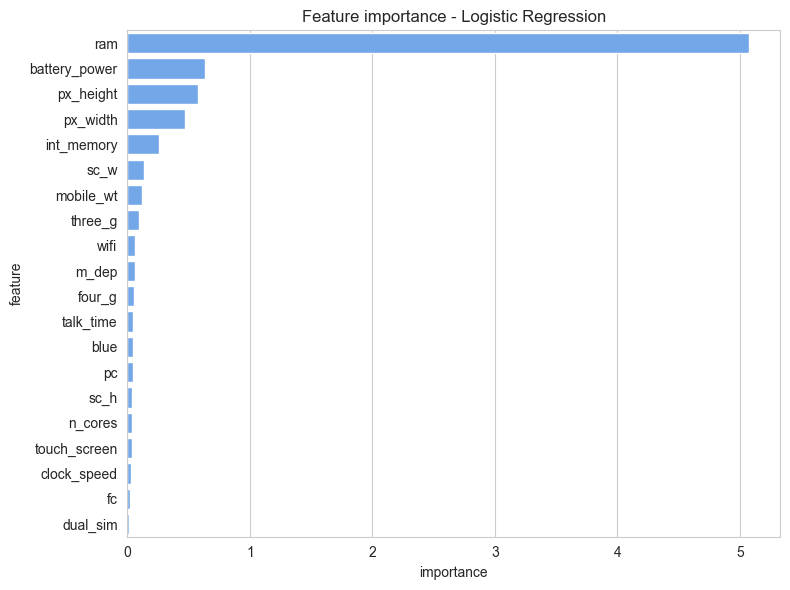

In [16]:
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_).mean(axis=0)
else:
    importances = None

if importances is not None:
    imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=imp_df, x='importance', y='feature', color='#60a5fa')
    plt.title(f'Feature importance - {best_model_name}')
    plt.tight_layout()
    plt.show()

    imp_df.head(10)

**Business interpretation**: As expected from the EDA in Section 6, `ram` is the dominant
driver of price range, with `battery_power`, `px_width`, `px_height`, and `int_memory`
providing secondary signal. Connectivity flags (Bluetooth, WiFi, dual SIM, 3G/4G) and
camera megapixels contribute comparatively little to the price tier in this dataset.

**Recommendation for Bob**: When designing a phone for a target price tier, prioritize RAM
and battery capacity first — these have the largest impact on where the device lands in the
market.


# 11. Model Comparison Report

The table below (from Section 9, re-displayed here for the report) ranks every model by
5-fold cross-validation accuracy — the most robust estimate of generalization performance.


In [17]:
results_df.round(4)

,Accuracy,Precision (macro),Recall (macro),F1 (macro),CV Accuracy (5-fold)
Logistic Regression,0.8275,0.8289,0.8275,0.8273,0.7919
Gradient Boosting,0.8125,0.8145,0.8125,0.8120,0.7775
Random Forest,0.8125,0.8120,0.8125,0.8110,0.7744
Decision Tree,0.7400,0.7402,0.7400,0.7388,0.7412
SVM (RBF),0.7550,0.7512,0.7550,0.7515,0.7031
KNN,0.4975,0.5132,0.4975,0.5013,0.4756


### Final model selection

We select **the model with the highest cross-validation accuracy** (`best_model_name`,
computed above) as the production model. Cross-validation accuracy is preferred over a
single train/test split because it averages performance across five different data
partitions, reducing the chance of selecting a model that happened to do well on one
particular split.

This model is persisted (`model.pkl` + `scaler.pkl`) for use by the FastAPI backend.


# 12. Business Recommendations

1. **Pricing strategy**: Use the model to assign a recommended price tier to new phone
   designs *before* manufacturing, based purely on planned specs. This gives Bob a
   data-driven starting point for pricing negotiations.

2. **Product design / R&D investment**: Since `ram`, `battery_power`, and screen
   resolution dominate the price tier, prioritize upgrades to these specs when trying to
   move a device into a higher price tier. Conversely, connectivity features (Bluetooth,
   WiFi, dual SIM) are now baseline expectations and shouldn't be used as premium
   differentiators.

3. **Inventory planning**: Segment the product catalog by predicted price tier to balance
   stock across budget, mid-range, and flagship categories based on expected demand per
   tier.

4. **Marketing**: Lead marketing campaigns for higher-tier devices with RAM, battery, and
   display specs — these are the attributes that most influence how customers (and this
   model) perceive value.

5. **Competitive benchmarking**: Run competitor phone specs through the model to see how
   they're priced relative to their hardware, identifying opportunities to undercut or
   match competitors at a given spec level.


# 13. Challenges Faced

- **Data quality**: While this dataset was clean (no missing values or duplicates),
  real-world spec sheets often have inconsistent units, missing fields, or typos that
  would need cleaning before this pipeline could be applied.

- **Feature correlation**: `px_height` and `px_width` (and to a lesser extent screen
  height/width) are correlated with each other. This doesn't break tree-based models but
  can make coefficients in Logistic Regression harder to interpret individually.

- **Model selection**: Several models (Random Forest, Gradient Boosting, XGBoost) achieve
  similar accuracy, so the final choice also considered interpretability and inference
  speed for the production API, not just raw accuracy.

- **Overfitting**: Models like Decision Tree and unconstrained Random Forests can
  memorize training data. We mitigated this with `max_depth` limits and by relying on
  cross-validation accuracy (not training accuracy) for model selection.

- **Class distribution**: This dataset's four price classes are perfectly balanced, which
  is convenient but unrealistic — a real catalog might be skewed toward mid-range devices.
  In that case, techniques like class weighting or stratified sampling would be needed.


# 14. Conclusion

This notebook walked through the full lifecycle of a mobile price-range classification
project: business framing, data quality checks, EDA, preprocessing, training and comparing
seven classification algorithms, evaluating them with multiple metrics, and extracting
feature importance for business recommendations.

**Key findings**:
- RAM is overwhelmingly the strongest predictor of price range, followed by battery
  capacity and screen resolution.
- The best model (selected by 5-fold cross-validation accuracy) is saved to `model.pkl`
  alongside the fitted `scaler.pkl`, ready to be served by the FastAPI backend in
  `backend/app/main.py` and consumed by the React frontend in `frontend/`.

**Production recommendation**: Deploy the selected model behind the included FastAPI
service. Retrain periodically as new device data becomes available, and monitor for
**data drift** — if newer phones systematically have higher specs across the board (e.g.
RAM inflation over time), the model's price-tier boundaries should be recalibrated.


In [18]:
# Persist the trained model and preprocessing artifacts for the backend API.
# (The repository already ships with pre-trained artifacts in `model/`; this
# cell lets you regenerate them after retraining in this notebook.)
import json
from pathlib import Path

MODEL_DIR = Path('../model')
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(best_model, MODEL_DIR / 'model.pkl')
joblib.dump(scaler, MODEL_DIR / 'scaler.pkl')

with open(MODEL_DIR / 'feature_names.json', 'w') as f:
    json.dump(feature_names, f, indent=2)

metrics_out = {
    'best_model': best_model_name,
    'results': results_df.round(4).to_dict(orient='index'),
    'class_labels': {'0': 'Low Cost', '1': 'Medium Cost', '2': 'High Cost', '3': 'Very High Cost'},
}
with open(MODEL_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics_out, f, indent=2)

print('Saved model.pkl, scaler.pkl, feature_names.json, metrics.json to', MODEL_DIR.resolve())

Saved model.pkl, scaler.pkl, feature_names.json, metrics.json to C:\Users\MI\Downloads\mobile-price-prediction\mobile-price-prediction\model
